<a href="https://colab.research.google.com/github/kvarun2300/Video-Game-Sales/blob/main/Video-Game-Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [49]:
df1= pd.read_csv('/content/sample_data/games.csv')

In [50]:
df1.head(10)

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,Elden Ring,"Feb 25, 2022","['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K
1,1,Hades,"Dec 10, 2019",['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K
2,2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K
3,3,Undertale,"Sep 15, 2015","['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K
4,4,Hollow Knight,"Feb 24, 2017",['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']","[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K
5,5,Minecraft,"Nov 18, 2011",['Mojang Studios'],4.3,2.3K,2.3K,"['Adventure', 'Simulator']",['Minecraft is what you make of it. Unfortunat...,33K,1.8K,1.1K,230
6,6,Omori,"Dec 25, 2020","['OMOCAT', 'PLAYISM']",4.2,1.6K,1.6K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","[""The best game I've played in my life"", ""omor...",7.2K,1.1K,4.5K,3.8K
7,7,Metroid Dread,"Oct 07, 2021","['Nintendo', 'MercurySteam']",4.3,2.1K,2.1K,"['Adventure', 'Platform']",['Have only been a Metroid fan for couple of y...,9.2K,759,3.4K,3.3K
8,8,Among Us,"Jun 15, 2018",['InnerSloth'],3.0,867,867,"['Indie', 'Strategy']","[""it's a solid party game. i'm bad at lying th...",25K,470,776,126
9,9,NieR: Automata,"Feb 23, 2017","['PlatinumGames', 'Square Enix']",4.3,2.9K,2.9K,"['Brawler', 'RPG']","['Holy shit', 'im carrying the weight of the w...",18K,1.1K,6.2K,3.6K


In [51]:
df1['Team'] = df1['Team'].str.replace('[', '').str.replace(']', '').str.replace("'", '')

In [52]:
df1['Genres'] = df1['Genres'].str.replace('[', '').str.replace(']', '').str.replace("'", '')
df1

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,Elden Ring,"Feb 25, 2022","Bandai Namco Entertainment, FromSoftware",4.5,3.9K,3.9K,"Adventure, RPG","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K
1,1,Hades,"Dec 10, 2019",Supergiant Games,4.3,2.9K,2.9K,"Adventure, Brawler, Indie, RPG",['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K
2,2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","Nintendo, Nintendo EPD Production Group No. 3",4.4,4.3K,4.3K,"Adventure, RPG",['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K
3,3,Undertale,"Sep 15, 2015","tobyfox, 8-4",4.2,3.5K,3.5K,"Adventure, Indie, RPG, Turn Based Strategy",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K
4,4,Hollow Knight,"Feb 24, 2017",Team Cherry,4.4,3K,3K,"Adventure, Indie, Platform","[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,1507,Back to the Future: The Game,"Dec 22, 2010",Telltale Games,3.2,94,94,"Adventure, Point-and-Click",['Very enjoyable game. The story adds onto the...,763,5,223,67
1508,1508,Team Sonic Racing,"May 21, 2019","Sumo Digital, Sega",2.9,264,264,"Arcade, Racing","['jogo morto mas bom', 'not my cup of tea', ""C...",1.5K,49,413,107
1509,1509,Dragon's Dogma,"May 22, 2012",Capcom,3.7,210,210,"Brawler, RPG","['Underrated.', 'A grandes rasgos, es como un ...",1.1K,45,487,206
1510,1510,Baldur's Gate 3,"Oct 06, 2020",Larian Studios,4.1,165,165,"Adventure, RPG, Strategy, Tactical, Turn Based...",['Bu türe bu oyunla girmeye çalışmak hataydı s...,269,79,388,602


In [53]:
def convert_k(value):
    if isinstance(value, str) and 'K' in value:
        return int(float(value.replace('K', '')) * 1000)
    return int(value)

df1['Plays'] = df1['Plays'].apply(convert_k)
df1['Playing'] = df1['Playing'].apply(convert_k)
df1['Backlogs'] = df1['Backlogs'].apply(convert_k)
df1['Wishlist'] = df1['Wishlist'].apply(convert_k)
df1['Times Listed'] = df1['Times Listed'].apply(convert_k)
df1['Number of Reviews'] = df1['Number of Reviews'].apply(convert_k)

df1

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,Elden Ring,"Feb 25, 2022","Bandai Namco Entertainment, FromSoftware",4.5,3900,3900,"Adventure, RPG","[""The first playthrough of elden ring is one o...",17000,3800,4600,4800
1,1,Hades,"Dec 10, 2019",Supergiant Games,4.3,2900,2900,"Adventure, Brawler, Indie, RPG",['convinced this is a roguelike for people who...,21000,3200,6300,3600
2,2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","Nintendo, Nintendo EPD Production Group No. 3",4.4,4300,4300,"Adventure, RPG",['This game is the game (that is not CS:GO) th...,30000,2500,5000,2600
3,3,Undertale,"Sep 15, 2015","tobyfox, 8-4",4.2,3500,3500,"Adventure, Indie, RPG, Turn Based Strategy",['soundtrack is tied for #1 with nier automata...,28000,679,4900,1800
4,4,Hollow Knight,"Feb 24, 2017",Team Cherry,4.4,3000,3000,"Adventure, Indie, Platform","[""this games worldbuilding is incredible, with...",21000,2400,8300,2300
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,1507,Back to the Future: The Game,"Dec 22, 2010",Telltale Games,3.2,94,94,"Adventure, Point-and-Click",['Very enjoyable game. The story adds onto the...,763,5,223,67
1508,1508,Team Sonic Racing,"May 21, 2019","Sumo Digital, Sega",2.9,264,264,"Arcade, Racing","['jogo morto mas bom', 'not my cup of tea', ""C...",1500,49,413,107
1509,1509,Dragon's Dogma,"May 22, 2012",Capcom,3.7,210,210,"Brawler, RPG","['Underrated.', 'A grandes rasgos, es como un ...",1100,45,487,206
1510,1510,Baldur's Gate 3,"Oct 06, 2020",Larian Studios,4.1,165,165,"Adventure, RPG, Strategy, Tactical, Turn Based...",['Bu türe bu oyunla girmeye çalışmak hataydı s...,269,79,388,602


In [54]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1512 non-null   int64  
 1   Title              1512 non-null   object 
 2   Release Date       1512 non-null   object 
 3   Team               1511 non-null   object 
 4   Rating             1499 non-null   float64
 5   Times Listed       1512 non-null   int64  
 6   Number of Reviews  1512 non-null   int64  
 7   Genres             1512 non-null   object 
 8   Reviews            1512 non-null   object 
 9   Plays              1512 non-null   int64  
 10  Playing            1512 non-null   int64  
 11  Backlogs           1512 non-null   int64  
 12  Wishlist           1512 non-null   int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 153.7+ KB


In [55]:
cols = ['Title', 'Release Date','Team','Rating','Times Listed',
        'Number of Reviews','Genres','Plays','Playing','Backlogs','Wishlist']

duplicates = df1[df1.duplicated(subset=cols, keep=False)]
df1 = df1.drop_duplicates(subset=cols)

In [56]:
df1.shape

(1120, 13)

In [57]:
df1[df1['Release Date'].str.contains('TBD', na=False)]

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Reviews,Plays,Playing,Backlogs,Wishlist
644,644,Deltarune,releases on TBD,tobyfox,4.3,313,313,"Adventure, Indie, Music, Puzzle, RPG","['Spamton is so hot, I want to kiss him in the...",1300,83,468,617
649,649,Death Stranding 2,releases on TBD,Kojima Productions,NaN,105,105,"Adventure, Shooter",[],3,0,209,644
1252,1252,Elden Ring: Shadow of the Erdtree,releases on TBD,"FromSoftware, Bandai Namco Entertainment",4.8,18,18,"Adventure, RPG",['I really loved that they integrated Family G...,1,0,39,146


In [58]:
df1 = df1[df1['Release Date'] != 'releases on TBD']


In [86]:
df1 = df1.dropna()
df1.isnull().sum()
df1 = df1.drop(columns=['Reviews'])

df1.shape
df1

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Plays,Playing,Backlogs,Wishlist,backlog_to_wishlist_ratio,Year
0,0,Elden Ring,2022-02-25,"Bandai Namco Entertainment, FromSoftware",4.5,3900,3900,"Adventure, RPG",17000,3800,4600,4800,0.958333,2022
1,1,Hades,2019-12-10,Supergiant Games,4.3,2900,2900,"Adventure, Brawler, Indie, RPG",21000,3200,6300,3600,1.750000,2019
2,2,The Legend of Zelda: Breath of the Wild,2017-03-03,"Nintendo, Nintendo EPD Production Group No. 3",4.4,4300,4300,"Adventure, RPG",30000,2500,5000,2600,1.923077,2017
3,3,Undertale,2015-09-15,"tobyfox, 8-4",4.2,3500,3500,"Adventure, Indie, RPG, Turn Based Strategy",28000,679,4900,1800,2.722222,2015
4,4,Hollow Knight,2017-02-24,Team Cherry,4.4,3000,3000,"Adventure, Indie, Platform",21000,2400,8300,2300,3.608696,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,1507,Back to the Future: The Game,2010-12-22,Telltale Games,3.2,94,94,"Adventure, Point-and-Click",763,5,223,67,3.328358,2010
1508,1508,Team Sonic Racing,2019-05-21,"Sumo Digital, Sega",2.9,264,264,"Arcade, Racing",1500,49,413,107,3.859813,2019
1509,1509,Dragon's Dogma,2012-05-22,Capcom,3.7,210,210,"Brawler, RPG",1100,45,487,206,2.364078,2012
1510,1510,Baldur's Gate 3,2020-10-06,Larian Studios,4.1,165,165,"Adventure, RPG, Strategy, Tactical, Turn Based...",269,79,388,602,0.644518,2020


In [88]:
df1.to_csv('df1_cleaned.csv', index=False)

### What are the top-rated games by user reviews?

<Axes: xlabel='Rating', ylabel='Title'>

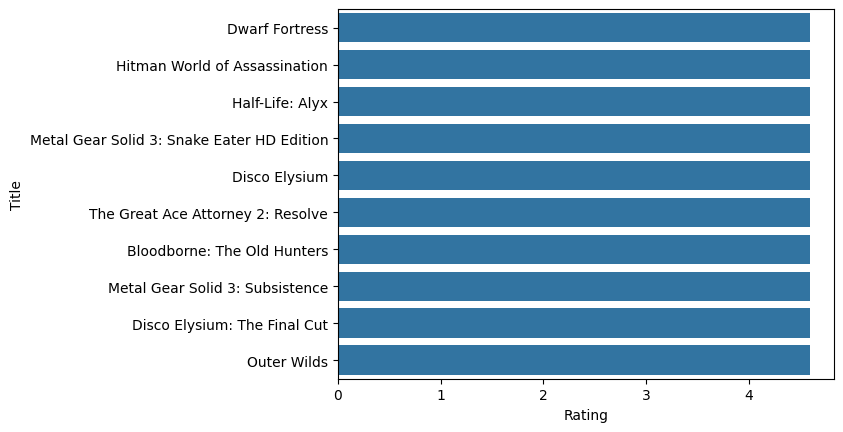

In [60]:
top_rated =df1.sort_values(by='Rating', ascending=False).head(10)
sns.barplot(
    data=top_rated,
    x='Rating',
    y='Title',
    order=top_rated.sort_values('Rating')['Title']
)

### Which developers (Teams) have the highest average ratings?

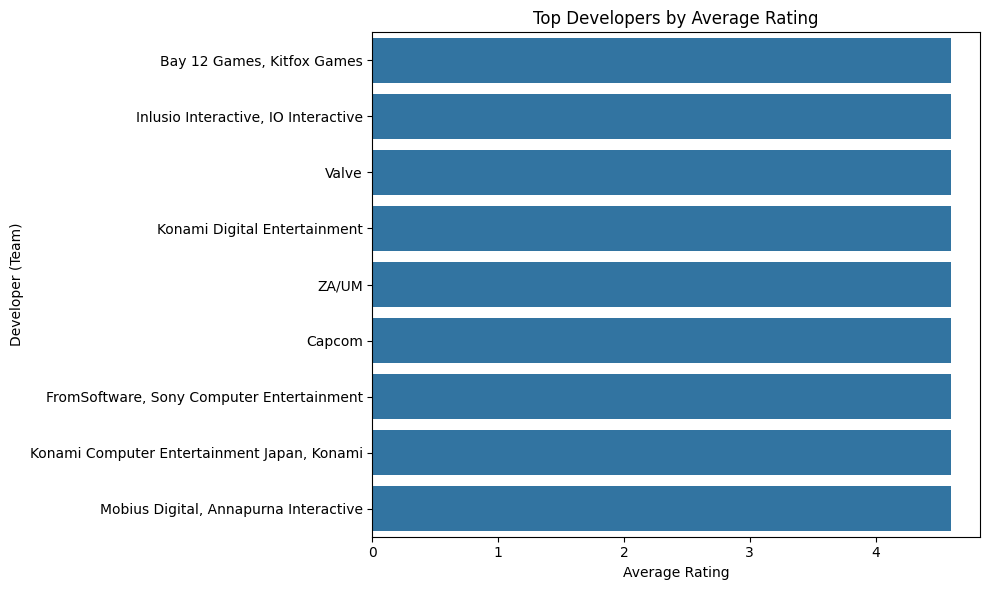

In [61]:
top_teams = df1.sort_values(by='Rating', ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_teams,
    x='Rating',
    y='Team'
)

plt.title('Top Developers by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Developer (Team)')

plt.tight_layout()
plt.show()

### What are the most common genres in the dataset?

                 Genre  Count
0            adventure    717
1                  rpg    359
2              shooter    260
3             platform    241
4                indie    205
5               puzzle    131
6             strategy    116
7              brawler    104
8            simulator     94
9  turn based strategy     71


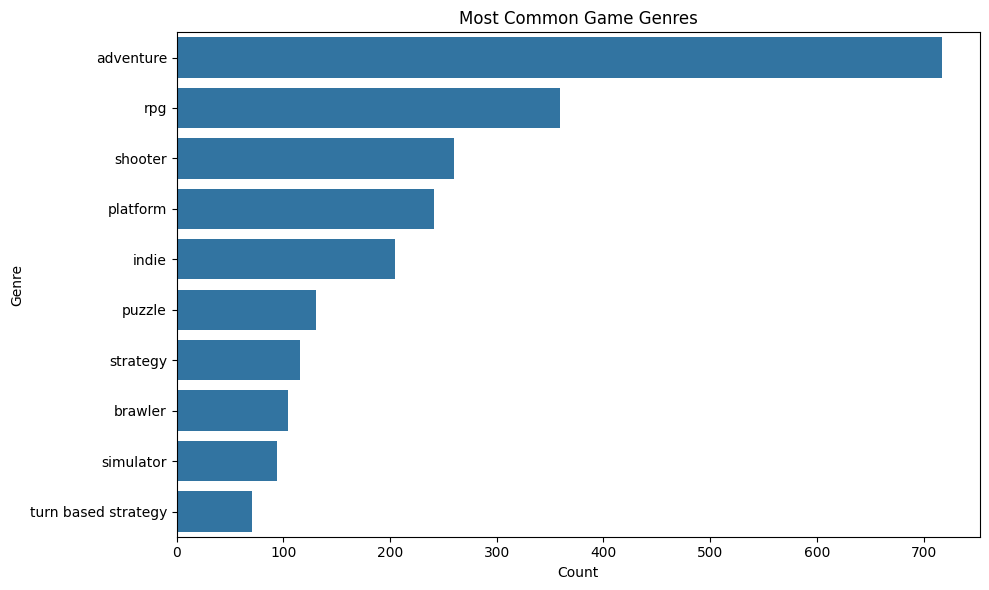

In [62]:
df_genres = df1.assign(Genres=df1['Genres'].str.split(', ')).explode('Genres')
df_genres['Genres'] = df_genres['Genres'].str.strip().str.lower()
genre_counts = df_genres['Genres'].value_counts().reset_index()
genre_counts.columns = ['Genre', 'Count']
top_genres = genre_counts.head(10)
print(top_genres)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_genres,
    x='Count',
    y='Genre'
)

plt.title('Most Common Game Genres')
plt.xlabel('Count')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

### Which games have the highest backlog compared to wishlist?

In [63]:
df1['backlog_to_wishlist_ratio'] = df1['Backlogs'] / df1['Wishlist']
top_games = df1.sort_values(
    by='backlog_to_wishlist_ratio',
    ascending=False
).head(10)
top_games[['Title', 'Backlogs', 'Wishlist', 'backlog_to_wishlist_ratio']]

,Title,Backlogs,Wishlist,backlog_to_wishlist_ratio
661,Paladins,188,16,11.750000
1289,Figment,392,35,11.200000
842,Fortnite,470,47,10.000000
959,Pokémon Go,197,22,8.954545
727,Half-Life: Opposing Force,838,95,8.821053
1023,Destiny 2,845,103,8.203883
1053,Brawlhalla,294,36,8.166667
1119,BioShock 2 Remastered,2000,246,8.130081
1129,Borderlands: The Pre-Sequel,1900,238,7.983193
1201,PUBG: Battlegrounds,253,32,7.906250


### What is the game release trend across years?

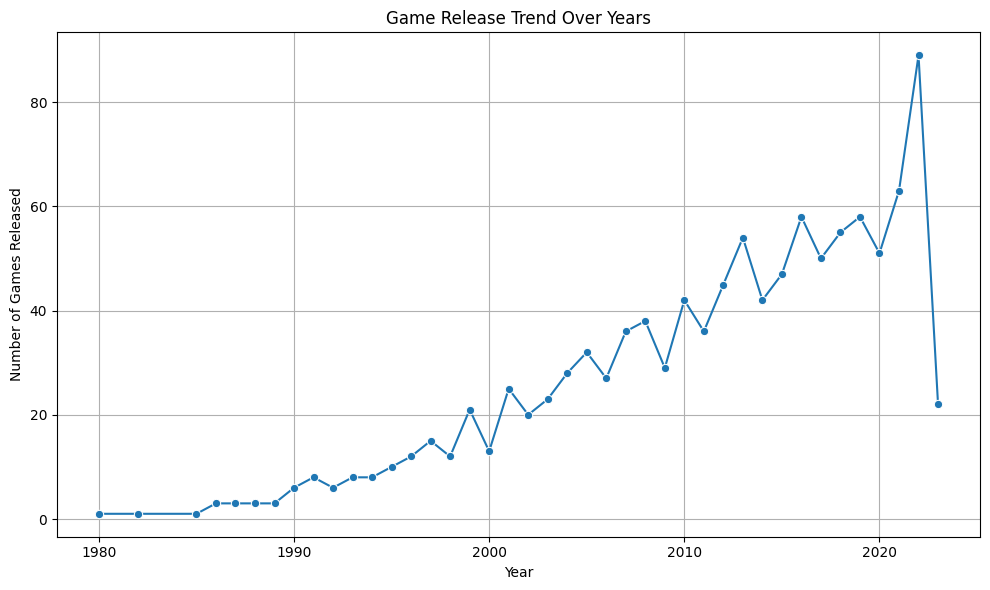

In [64]:
df1['Release Date'] = pd.to_datetime(df1['Release Date'], errors='coerce')
df1['Year'] = df1['Release Date'].dt.year
year_trend = df1['Year'].value_counts().sort_index().reset_index()
year_trend.columns = ['Year', 'Number of Games']

plt.figure(figsize=(10,6))

sns.lineplot(
    data=year_trend,
    x='Year',
    y='Number of Games',
    marker='o'
)

plt.title('Game Release Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Games Released')

plt.grid(True)
plt.tight_layout()
plt.show()

### What is the distribution of user ratings?

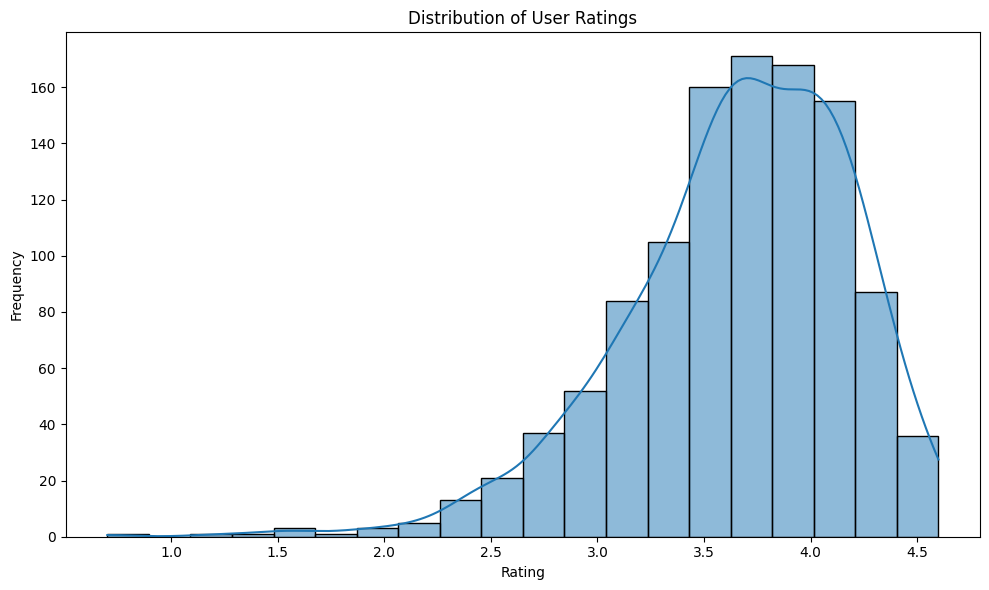

In [65]:
df_ratings = df1.dropna(subset=['Rating'])

plt.figure(figsize=(10,6))

sns.histplot(
    data=df_ratings,
    x='Rating',
    bins=20,
    kde=True
)

plt.title('Distribution of User Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### What are the top 10 most wishlisted games?

In [66]:
df_wishlist = df1.dropna(subset=['Wishlist'])
top_wishlist = df_wishlist.sort_values(by='Wishlist', ascending=False).head(10)
top_wishlist[['Title', 'Wishlist']]

,Title,Wishlist
0,Elden Ring,4800
6,Omori,3800
31,NieR Replicant ver.1.22474487139...,3700
1,Hades,3600
9,NieR: Automata,3600
35,Sekiro: Shadows Die Twice,3400
11,Stray,3400
25,God of War Ragnarök,3300
14,Bloodborne,3300
7,Metroid Dread,3300


### What’s the average number of plays per genre?

In [67]:
df_genres = df1.assign(Genres=df1['Genres'].str.split(', ')).explode('Genres')
df_genres['Genres'] = df_genres['Genres'].str.strip().str.lower()
genre_avg_plays = df_genres.groupby('Genres')['Plays'].mean().reset_index()
genre_avg_plays = genre_avg_plays.sort_values(by='Plays', ascending=False)
genre_avg_plays.head(10)



,Genres,Plays
7,moba,8750.000000
17,shooter,6186.038462
14,racing,6099.297297
10,platform,5660.041494
22,turn based strategy,5387.098592
1,adventure,5291.135286
3,brawler,5074.701923
16,rpg,4975.941504
18,simulator,4544.340426
21,tactical,4276.880952


### Which developer studios are the most productive and impactful?

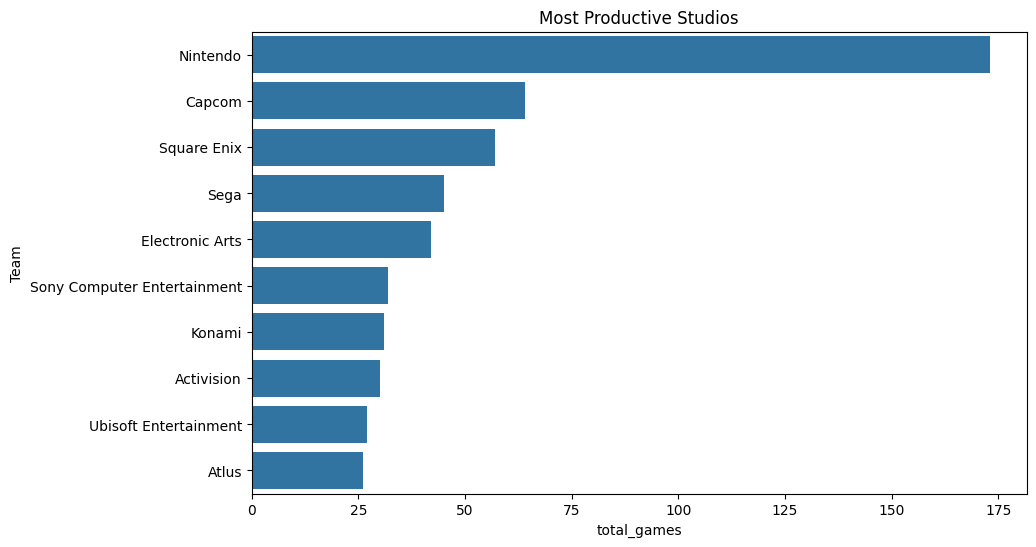

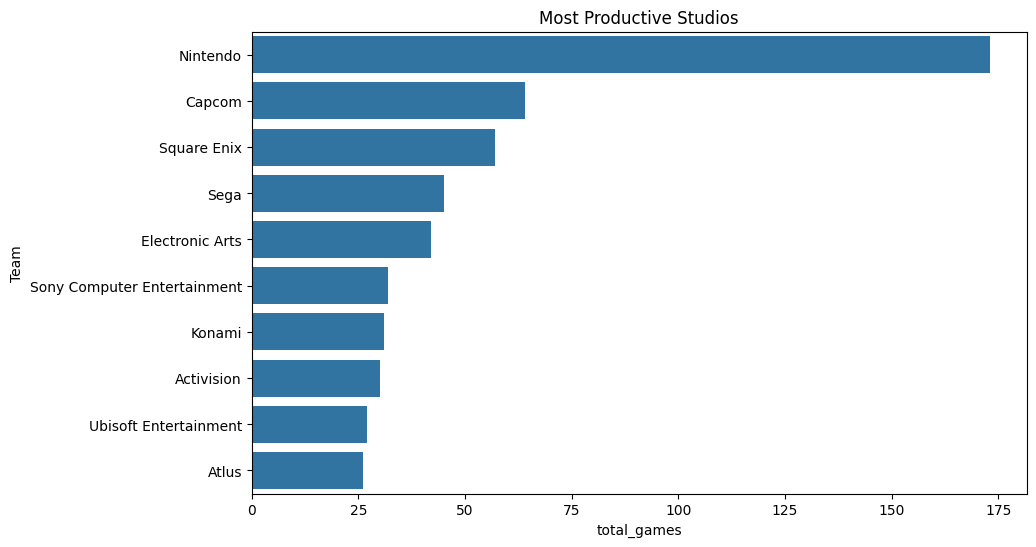

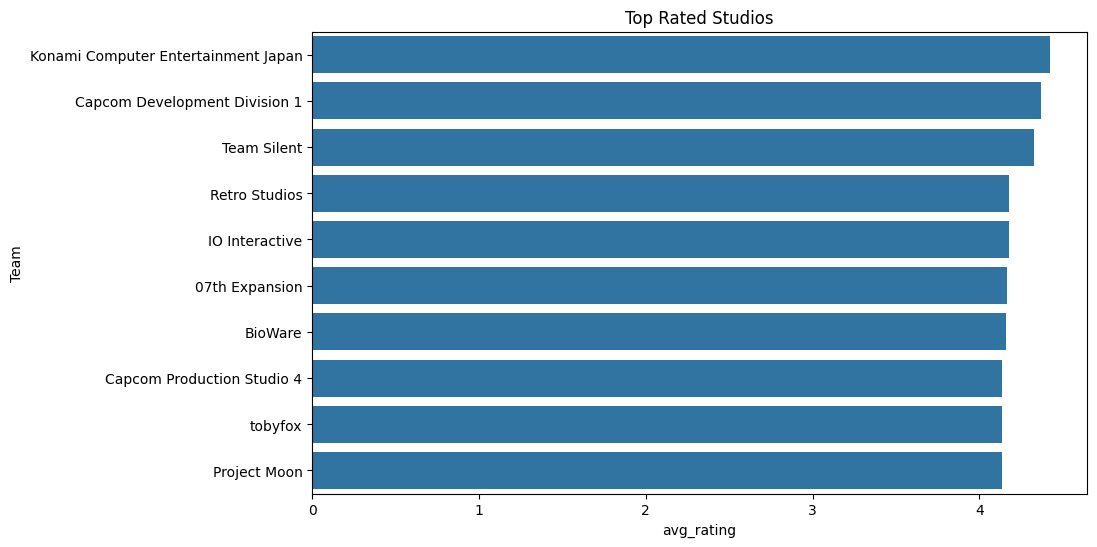

In [150]:
df_team = df1.assign(Team=df1['Team'].str.split(', ')).explode('Team')
team_stats = df_team.groupby('Team').agg(
    total_games=('Title', 'count'),
    avg_rating=('Rating', 'mean'),
    avg_plays=('Plays', 'mean')
).reset_index()

team_stats = team_stats[team_stats['total_games'] >= 3]

top_productive = team_stats.sort_values(by='total_games', ascending=False).head(10)

top_rated = team_stats.sort_values(by='avg_rating', ascending=False).head(10)

top_engaging = team_stats.sort_values(by='avg_plays', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_productive, x='total_games', y='Team')
plt.title('Most Productive Studios')
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=top_productive, x='total_games', y='Team')
plt.title('Most Productive Studios')
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=top_rated, x='avg_rating', y='Team')
plt.title('Top Rated Studios')
plt.show()

In [69]:
df2= pd.read_csv('/content/sample_data/vgsales.csv')

In [89]:
cols = ['Name', 'Platform','Year','Genre','Publisher','NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']

duplicates = df2[df2.duplicated(subset=cols, keep=False)]
df2 = df2.drop_duplicates(subset=cols)
df2.dropna()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,rank
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,1.0
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,1.0
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,2.0
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,3.0
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01,821.0
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01,556.0
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01,2161.0
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01,2163.0


In [90]:
df2.to_csv('df2_cleaned.csv', index=False)

### Which region generates the most game sales?

NA_Sales       4392.95
EU_Sales       2434.13
JP_Sales       1291.00
Other_Sales     797.75
dtype: float64


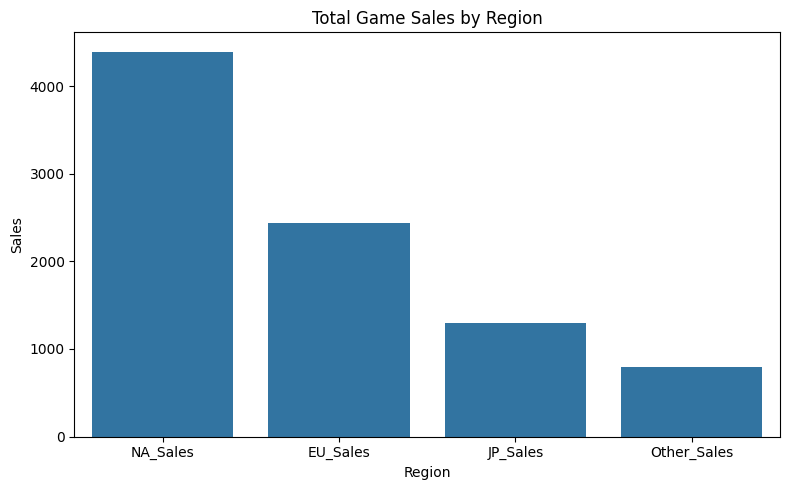

In [71]:
region_sales = df2[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
print(region_sales)
region_sales_df = region_sales.reset_index()
region_sales_df.columns = ['Region', 'Total Sales']

plt.figure(figsize=(8,5))

sns.barplot(
    data=region_sales_df,
    x='Region',
    y='Total Sales'
)

plt.title('Total Game Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

### What are the best-selling platforms?

   Platform  Global_Sales
16      PS2       1255.64
28     X360        979.96
17      PS3        957.84
26      Wii        926.69
4        DS        822.49
15       PS        730.66
6       GBA        318.50
19      PSP        296.28
18      PS4        278.10
13       PC        258.82


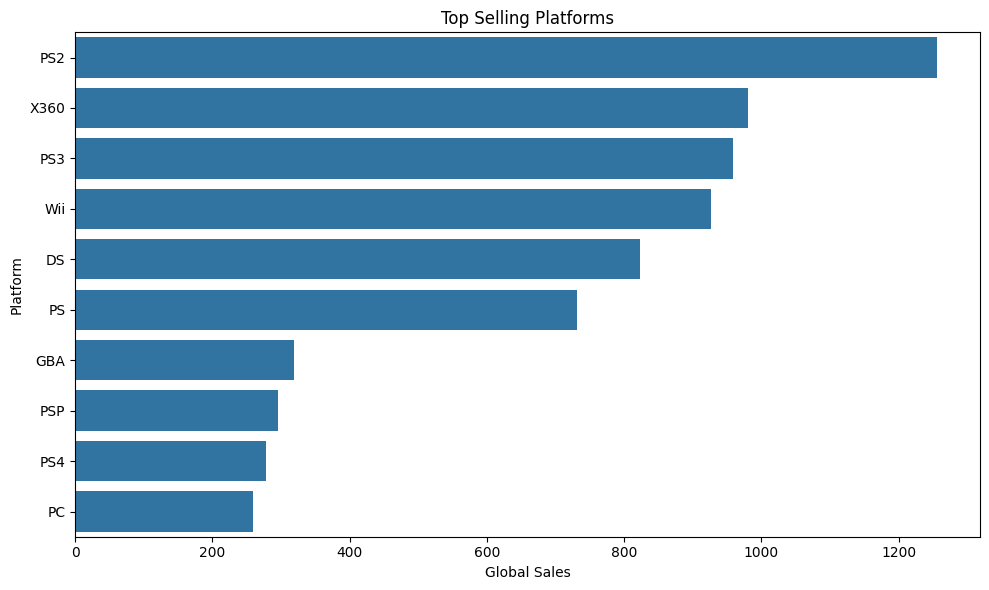

In [72]:
platform_sales = df2.groupby('Platform')['Global_Sales'].sum().reset_index()
platform_sales = platform_sales.sort_values(by='Global_Sales', ascending=False)
top_platforms = platform_sales.head(10)
print(top_platforms)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_platforms,
    x='Global_Sales',
    y='Platform'
)

plt.title('Top Selling Platforms')
plt.xlabel('Global Sales')
plt.ylabel('Platform')

plt.tight_layout()
plt.show()

### What’s the trend of game releases and sales over years?

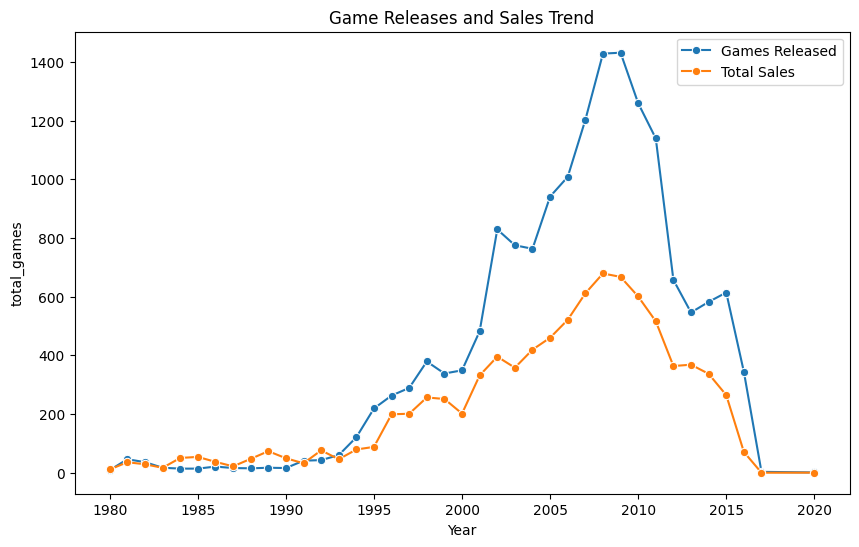

In [73]:
df_year = df2.dropna(subset=['Year'])
year_trend = df_year.groupby('Year').agg(
    total_games=('Name', 'count'),
    total_sales=('Global_Sales', 'sum')
).reset_index()

year_trend = year_trend.sort_values('Year')

plt.figure(figsize=(10,6))

sns.lineplot(data=year_trend, x='Year', y='total_games', marker='o', label='Games Released')
sns.lineplot(data=year_trend, x='Year', y='total_sales', marker='o', label='Total Sales')

plt.title('Game Releases and Sales Trend')
plt.legend()
plt.show()


### Who are the top publishers by sales?

                        Publisher  Global_Sales
359                      Nintendo       1786.54
138               Electronic Arts       1110.32
21                     Activision        727.46
456   Sony Computer Entertainment        607.50
525                       Ubisoft        474.72
494          Take-Two Interactive        399.54
488                           THQ        340.77
275  Konami Digital Entertainment        283.64
446                          Sega        272.99
347            Namco Bandai Games        254.09


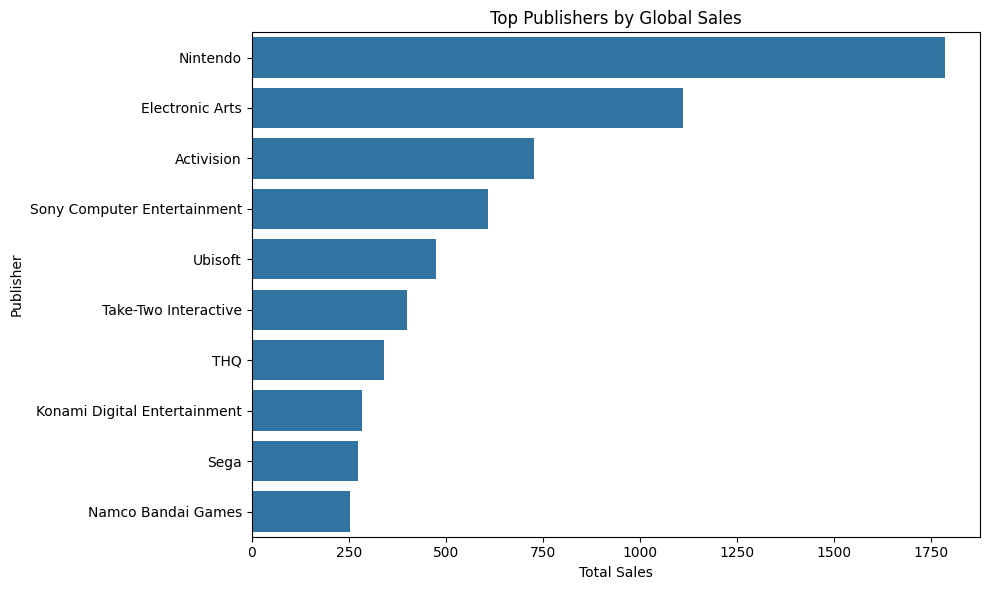

In [74]:
publisher_sales = df2.groupby('Publisher')['Global_Sales'].sum().reset_index()
publisher_sales = publisher_sales.sort_values(by='Global_Sales', ascending=False)
top_publishers = publisher_sales.head(10)
print(top_publishers)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_publishers,
    x='Global_Sales',
    y='Publisher'
)

plt.title('Top Publishers by Global Sales')
plt.xlabel('Total Sales')
plt.ylabel('Publisher')

plt.tight_layout()
plt.show()

### Which games are the top 10 best-sellers globally?

In [75]:
df_sales = df2.dropna(subset=['Global_Sales'])
top_games = df_sales.sort_values(by='Global_Sales', ascending=False).head(10)
top_games[['Name', 'Platform', 'Year', 'Global_Sales']]

,Name,Platform,Year,Global_Sales
0,Wii Sports,Wii,2006.0,82.74
1,Super Mario Bros.,NES,1985.0,40.24
2,Mario Kart Wii,Wii,2008.0,35.82
3,Wii Sports Resort,Wii,2009.0,33.00
4,Pokemon Red/Pokemon Blue,GB,1996.0,31.37
5,Tetris,GB,1989.0,30.26
6,New Super Mario Bros.,DS,2006.0,30.01
7,Wii Play,Wii,2006.0,29.02
8,New Super Mario Bros. Wii,Wii,2009.0,28.62
9,Duck Hunt,NES,1984.0,28.31


### How do regional sales compare for specific platforms?

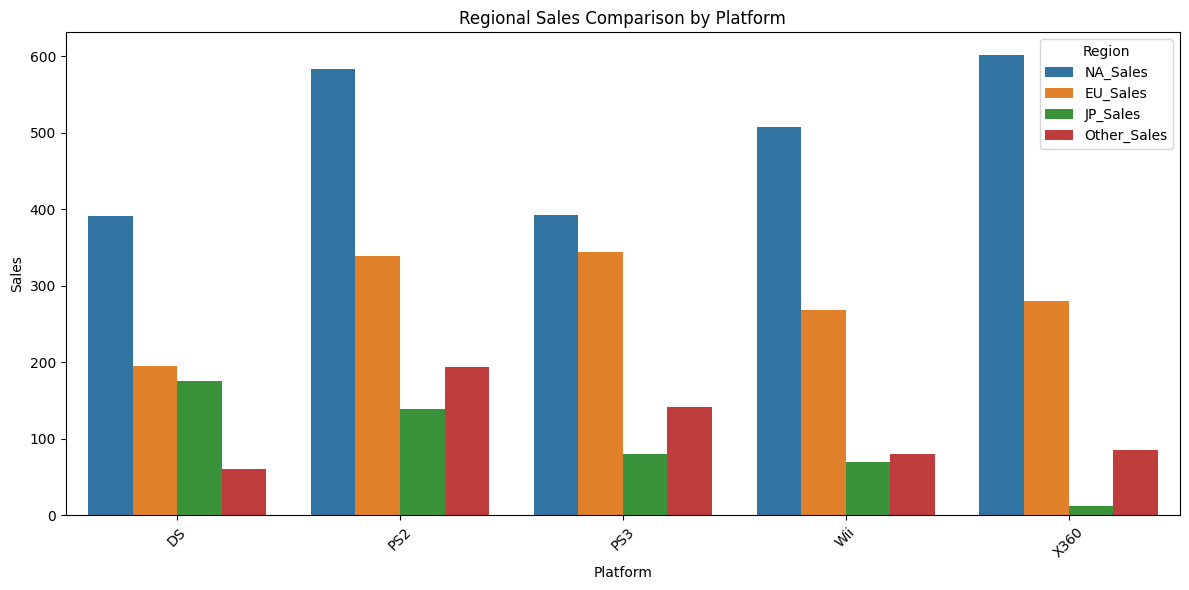

In [76]:
platform_region_sales = df2.groupby('Platform')[
    ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
].sum().reset_index()

top_platforms = df2.groupby('Platform')['Global_Sales'].sum() \
                   .sort_values(ascending=False).head(5).index

platform_region_sales = platform_region_sales[
    platform_region_sales['Platform'].isin(top_platforms)
]

platform_melted = platform_region_sales.melt(
    id_vars='Platform',
    var_name='Region',
    value_name='Sales'
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=platform_melted,
    x='Platform',
    y='Sales',
    hue='Region'
)

plt.title('Regional Sales Comparison by Platform')
plt.xlabel('Platform')
plt.ylabel('Sales')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### How has the market evolved by platform over time?

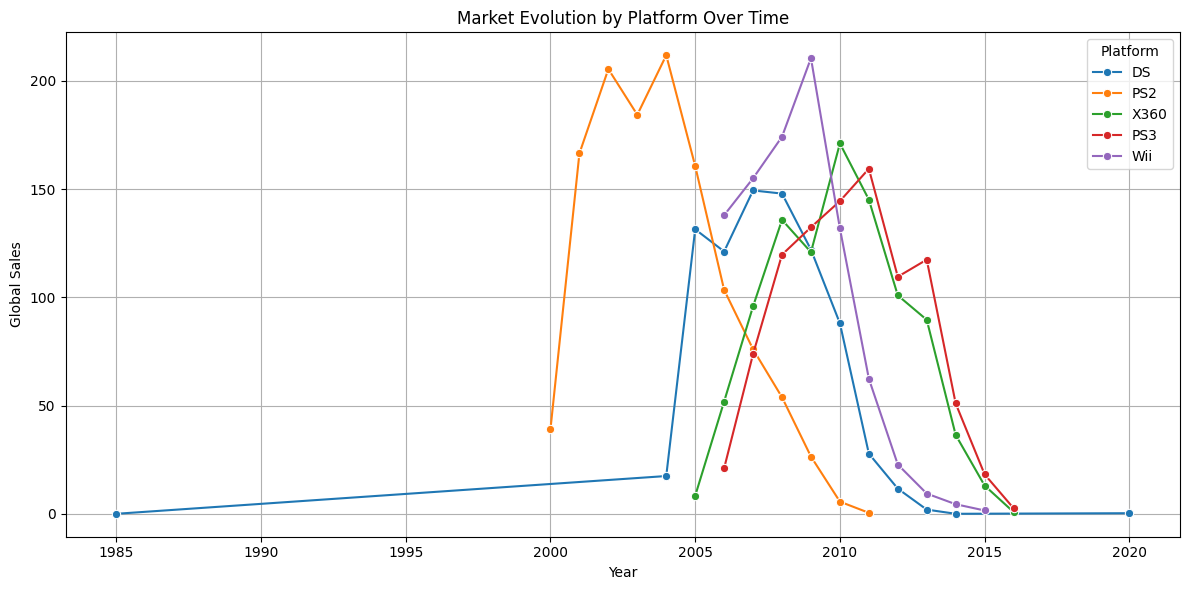

In [77]:
df_year = df2.dropna(subset=['Year'])
platform_trend = df_year.groupby(['Year', 'Platform'])['Global_Sales'] \
                        .sum().reset_index()
top_platforms = df2.groupby('Platform')['Global_Sales'] \
                   .sum().sort_values(ascending=False).head(5).index

platform_trend = platform_trend[
    platform_trend['Platform'].isin(top_platforms)
]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=platform_trend,
    x='Year',
    y='Global_Sales',
    hue='Platform',
    marker='o'
)

plt.title('Market Evolution by Platform Over Time')
plt.xlabel('Year')
plt.ylabel('Global Sales')

plt.grid(True)
plt.tight_layout()
plt.show()

### What are the regional genre preferences?

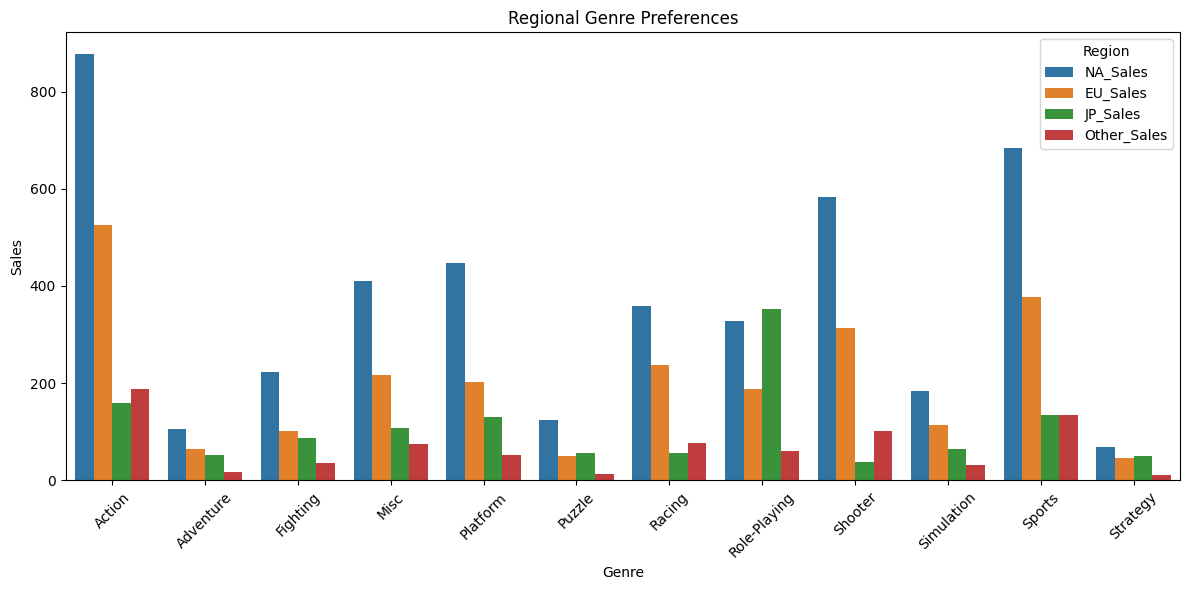

In [78]:
genre_region = df2.groupby('Genre')[
    ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
].sum().reset_index()

genre_melted = genre_region.melt(
    id_vars='Genre',
    var_name='Region',
    value_name='Sales'
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=genre_melted,
    x='Genre',
    y='Sales',
    hue='Region'
)

plt.title('Regional Genre Preferences')
plt.xlabel('Genre')
plt.ylabel('Sales')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### What’s the yearly sales change per region?

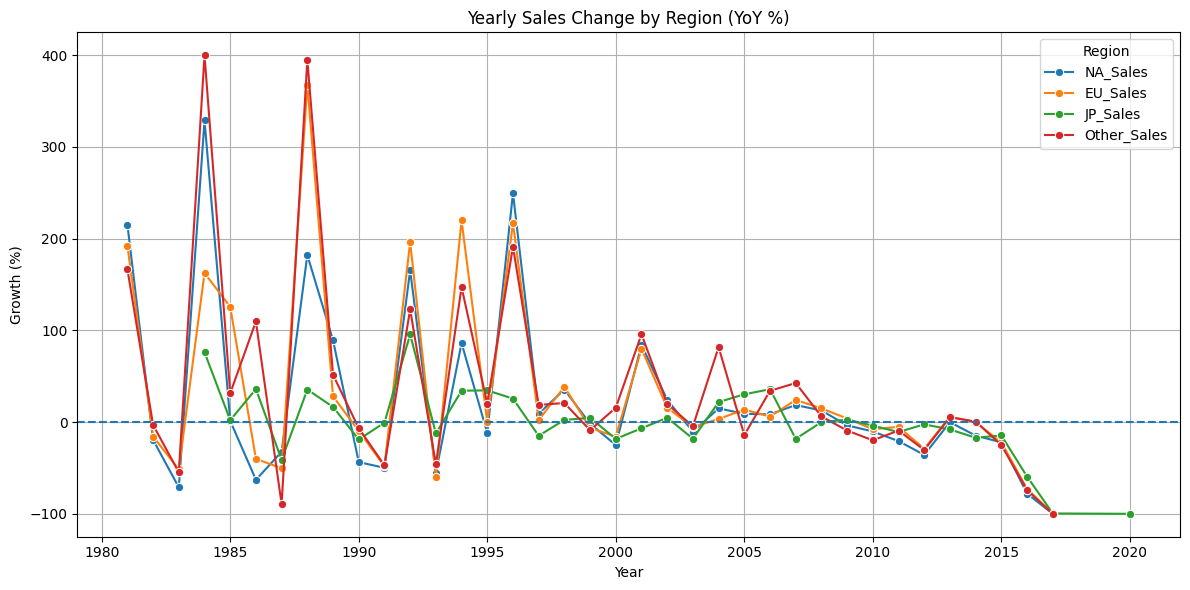

In [79]:
cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
df2[cols] = df2[cols].apply(pd.to_numeric, errors='coerce')

df_year = df2.dropna(subset=['Year'])
year_region_sales = df_year.groupby('Year')[cols].sum().reset_index()
year_region_sales = year_region_sales.sort_values('Year')

yoy_change = year_region_sales.copy()

for col in cols:
    yoy_change[col] = year_region_sales[col].pct_change() * 100


yoy_melted = yoy_change.melt(
    id_vars='Year',
    var_name='Region',
    value_name='YoY Change (%)'
)


plt.figure(figsize=(12,6))

sns.lineplot(
    data=yoy_melted,
    x='Year',
    y='YoY Change (%)',
    hue='Region',
    marker='o'
)

plt.title('Yearly Sales Change by Region (YoY %)')
plt.xlabel('Year')
plt.ylabel('Growth (%)')

plt.axhline(0, linestyle='--')  # zero growth line
plt.grid(True)
plt.tight_layout()
plt.show()

### What is the average sales per publisher?

In [80]:
publisher_avg = df2.groupby('Publisher')['Global_Sales'] \
                   .mean().reset_index()
publisher_avg = publisher_avg.sort_values(by='Global_Sales', ascending=False)
top_publishers = publisher_avg.head(10)

top_publishers



,Publisher,Global_Sales
385,Palcom,4.170000
424,Red Orb,2.620000
359,Nintendo,2.544929
40,Arena Entertainment,2.360000
522,UEP Systems,2.250000
426,RedOctane,2.170000
533,Valve,1.740000
219,Hello Games,1.600000
458,Sony Computer Entertainment Europe,1.592667
552,Westwood Studios,1.550000


### What are the top 5 best-selling games per platform?

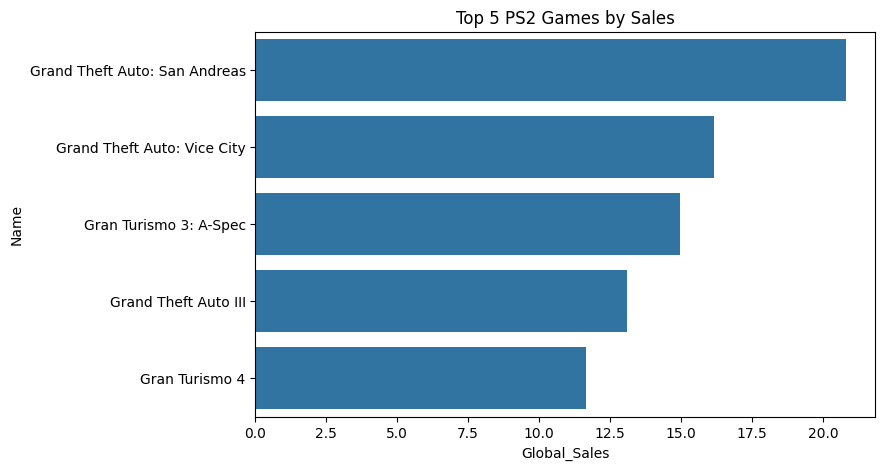

In [81]:
df2['rank'] = df2.groupby('Platform')['Global_Sales'].rank(method='first', ascending=False)
top5_per_platform = df2[df2['rank'] <= 5]
top5_per_platform = top5_per_platform.sort_values(
    ['Platform', 'rank']
)
top5_per_platform[['Platform', 'Name', 'Global_Sales', 'rank']]

ps2_top5 = top5_per_platform[top5_per_platform['Platform'] == 'PS2']

plt.figure(figsize=(8,5))
sns.barplot(data=ps2_top5, x='Global_Sales', y='Name')
plt.title('Top 5 PS2 Games by Sales')
plt.show()

In [98]:
games=pd.read_csv('/content/df1_cleaned.csv')
sales=pd.read_csv('/content/df2_cleaned.csv')

In [113]:
inner_merged_df = pd.merge(
    games,
    sales,
    left_on='Title',
    right_on='Name',
    how='inner'
)

inner_merged_df.shape
inner_merged_df = inner_merged_df.drop(columns=['Name','Year_y'])

inner_merged_df.to_csv('merged.csv', index=False)


In [128]:
inner_merged_df

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Plays,Playing,Backlogs,Wishlist,backlog_to_wishlist_ratio,Year_x,Rank,Platform,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,rank
0,5,Minecraft,2011-11-18,Mojang Studios,4.3,2300,2300,"Adventure, Simulator",33000,1800,1100,230,4.782609,2011,73,X360,Misc,Microsoft Game Studios,5.58,2.83,0.02,0.77,9.20,13.0
1,5,Minecraft,2011-11-18,Mojang Studios,4.3,2300,2300,"Adventure, Simulator",33000,1800,1100,230,4.782609,2011,169,PS3,Misc,Sony Computer Entertainment,1.97,2.51,0.00,0.94,5.42,25.0
2,5,Minecraft,2011-11-18,Mojang Studios,4.3,2300,2300,"Adventure, Simulator",33000,1800,1100,230,4.782609,2011,298,PS4,Misc,Sony Computer Entertainment Europe,1.38,1.87,0.12,0.65,4.02,15.0
3,5,Minecraft,2011-11-18,Mojang Studios,4.3,2300,2300,"Adventure, Simulator",33000,1800,1100,230,4.782609,2011,644,XOne,Misc,Microsoft Game Studios,1.43,0.76,0.00,0.22,2.41,14.0
4,5,Minecraft,2011-11-18,Mojang Studios,4.3,2300,2300,"Adventure, Simulator",33000,1800,1100,230,4.782609,2011,715,PSV,Misc,Sony Computer Entertainment Europe,0.28,0.79,0.87,0.32,2.25,1.0
5,5,Minecraft,2011-11-18,Mojang Studios,4.3,2300,2300,"Adventure, Simulator",33000,1800,1100,230,4.782609,2011,4515,WiiU,Misc,Microsoft Game Studios,0.18,0.09,0.14,0.03,0.43,45.0
6,12,God of War,2018-04-20,"Sony Interactive Entertainment, SIE Santa Moni...",4.2,2900,2900,"Adventure, Brawler, RPG",21000,1100,4800,2600,1.846154,2018,246,PS2,Action,Sony Computer Entertainment,2.71,1.29,0.02,0.43,4.45,26.0
7,13,Portal 2,2011-04-18,"Valve, Electronic Arts",4.4,2900,2900,"Adventure, Platform, Puzzle, Shooter",29000,471,3900,1200,3.250000,2011,791,X360,Shooter,Valve Software,1.41,0.51,0.01,0.17,2.10,106.0
8,13,Portal 2,2011-04-18,"Valve, Electronic Arts",4.4,2900,2900,"Adventure, Platform, Puzzle, Shooter",29000,471,3900,1200,3.250000,2011,1018,PS3,Shooter,Valve,0.83,0.63,0.02,0.25,1.74,123.0
9,13,Portal 2,2011-04-18,"Valve, Electronic Arts",4.4,2900,2900,"Adventure, Platform, Puzzle, Shooter",29000,471,3900,1200,3.250000,2011,2701,PC,Shooter,Valve Software,0.33,0.32,0.00,0.11,0.76,83.0


In [ ]:
merged=pd.read_csv('/content/merged.csv')

### Which game genres generate the most global sales?

           Genre  Global_Sales
0         Action       1751.18
10        Sports       1330.93
8        Shooter       1037.35
7   Role-Playing        927.37
4       Platform        831.37
3           Misc        809.96
6         Racing        732.04
2       Fighting        448.91
9     Simulation        392.20
5         Puzzle        244.95


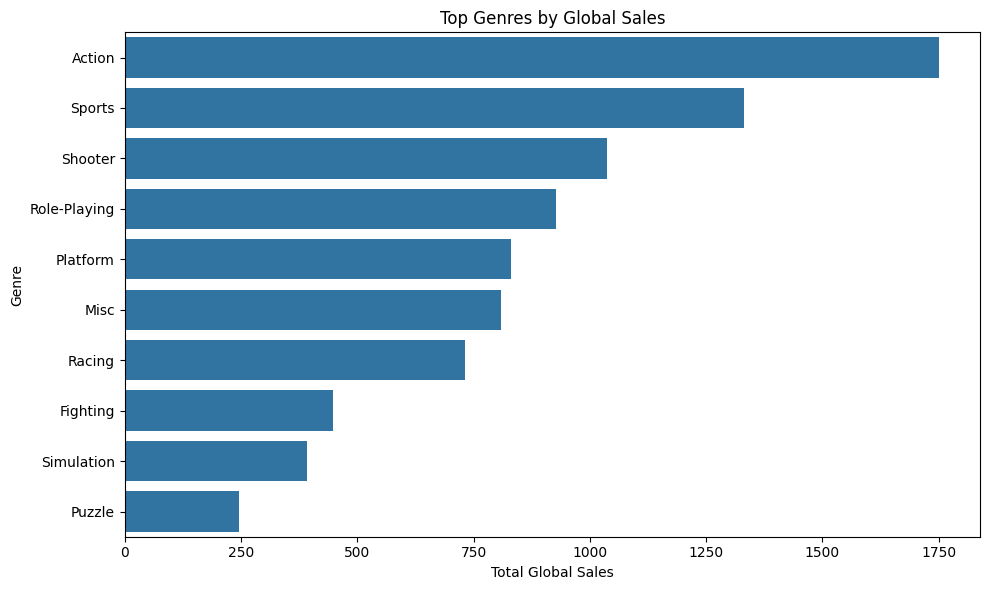

In [116]:

genre_sales = df2.groupby('Genre')['Global_Sales'].sum().reset_index()
genre_sales = genre_sales.sort_values(by='Global_Sales', ascending=False)
top_genres = genre_sales.head(10)
print(top_genres)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_genres,
    x='Global_Sales',
    y='Genre'
)

plt.title('Top Genres by Global Sales')
plt.xlabel('Total Global Sales')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

### How does user rating affect global sales?

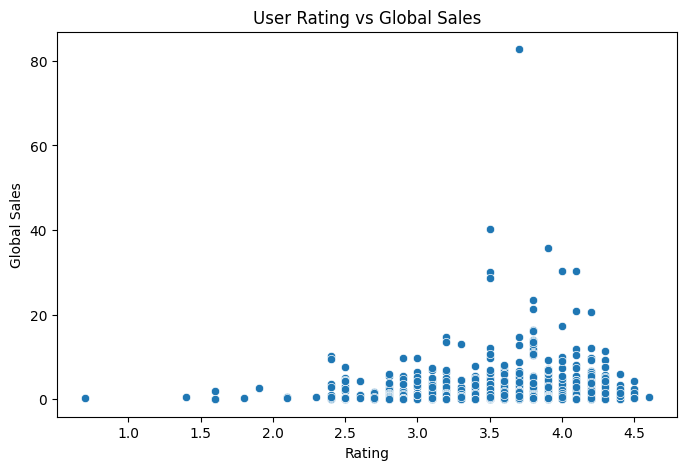

In [120]:
merged['Rating'] = pd.to_numeric(merged['Rating'], errors='coerce')
merged['Global_Sales'] = pd.to_numeric(merged['Global_Sales'], errors='coerce')

merged_df = merged.dropna(subset=['Rating', 'Global_Sales'])
merged_df[['Rating', 'Global_Sales']].corr()

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=merged_df,
    x='Rating',
    y='Global_Sales'
)

plt.title('User Rating vs Global Sales')
plt.xlabel('Rating')
plt.ylabel('Global Sales')

plt.show()


### Which platforms have the most games with high ratings (e.g., above 4)?

   Platform  high_rated_games
9       PS2                23
10      PS3                19
7        PC                16
8        PS                14
18     X360                13
15     SNES                12
1        DS                11
11      PS4                11
0       3DS                 9
4        GC                 9


<Axes: xlabel='high_rated_games', ylabel='Platform'>

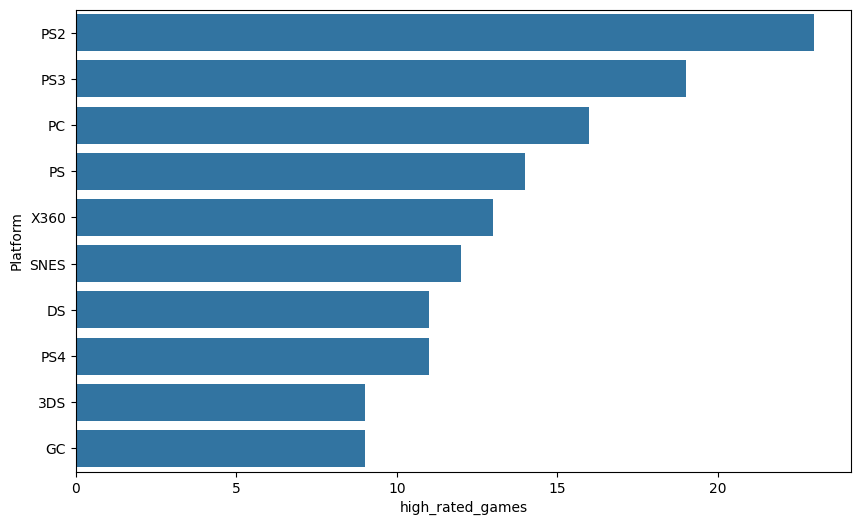

In [123]:
merged['Rating'] = pd.to_numeric(merged['Rating'], errors='coerce')
high_rated = merged[merged['Rating'] > 4]
platform_counts = high_rated.groupby('Platform')['Title'].count().reset_index(name='high_rated_games')
platform_counts = platform_counts.sort_values(
    by='high_rated_games',
    ascending=False
)
top_platforms = platform_counts.head(10)
print(top_platforms)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_platforms,
    x='high_rated_games',
    y='Platform'
)

### What’s the trend of releases and sales over time?

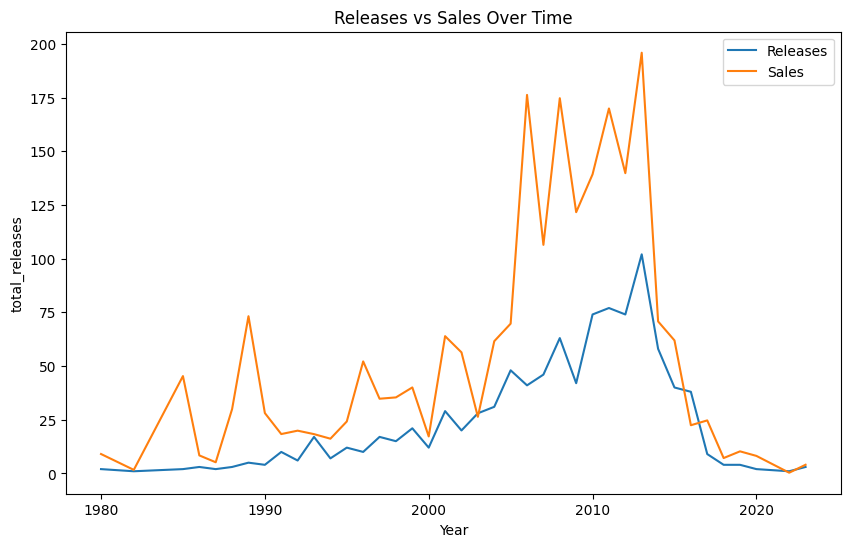

In [131]:
merged['Release Date'] = pd.to_datetime(
    merged_df['Release Date'],
    errors='coerce'
)
merged['Year'] = merged['Release Date'].dt.year
merged['Global_Sales'] = pd.to_numeric(merged['Global_Sales'], errors='coerce')

df_year = merged.dropna(subset=['Year'])
year_trend = df_year.groupby('Year').agg(
    total_releases=('Title', 'count'),
    total_sales=('Global_Sales', 'sum')
).reset_index()

year_trend = year_trend.sort_values('Year')

plt.figure(figsize=(10,6))

sns.lineplot(data=year_trend, x='Year', y='total_releases', label='Releases')
sns.lineplot(data=year_trend, x='Year', y='total_sales', label='Sales')

plt.title('Releases vs Sales Over Time')
plt.legend()
plt.show()

### Do highly wishlisted games lead to more sales?

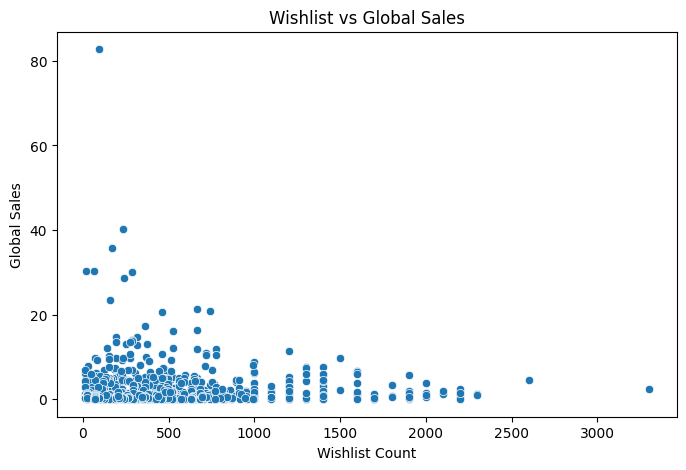

In [132]:
merged['Wishlist'] = pd.to_numeric(merged['Wishlist'], errors='coerce')
merged['Global_Sales'] = pd.to_numeric(merged['Global_Sales'], errors='coerce')

df_wish = merged.dropna(subset=['Wishlist', 'Global_Sales'])

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_wish,
    x='Wishlist',
    y='Global_Sales'
)

plt.title('Wishlist vs Global Sales')
plt.xlabel('Wishlist Count')
plt.ylabel('Global Sales')

plt.show()

### Which genres have the highest engagement but lowest sales?

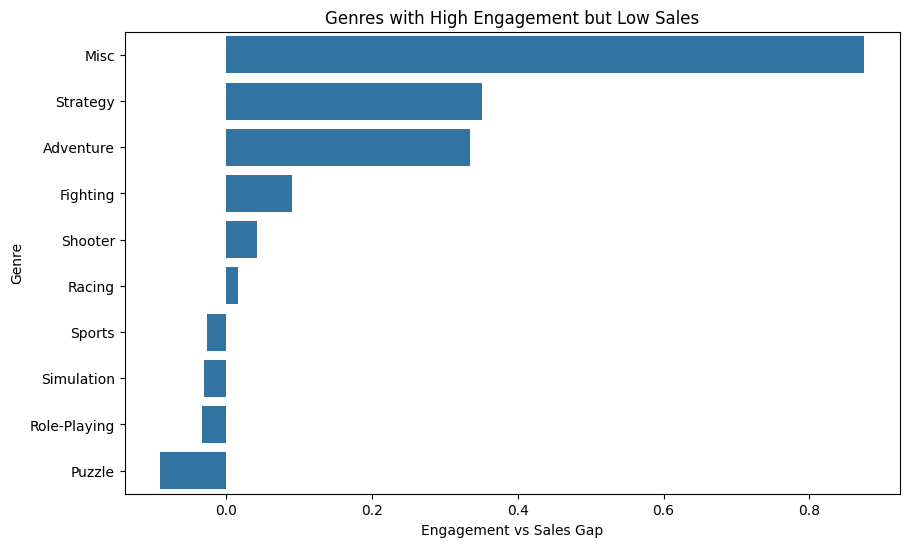

,Genre,avg_plays,total_sales,gap
3,Misc,10422.222222,83.91,0.875380
11,Strategy,5854.666667,11.85,0.350972
1,Adventure,6047.400000,37.11,0.334674
2,Fighting,4710.000000,68.47,0.090402
8,Shooter,8415.337423,400.68,0.042394
6,Racing,4900.000000,126.37,0.017269
10,Sports,4442.875000,113.38,-0.025222
9,Simulation,3384.692308,28.94,-0.029555
7,Role-Playing,5920.267123,239.12,-0.032744
5,Puzzle,3805.555556,98.76,-0.090498


In [137]:
genre_stats = merged.groupby('Genre').agg(
    avg_plays=('Plays', 'mean'),
    total_sales=('Global_Sales', 'sum')
).reset_index()

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

genre_stats[['plays_norm', 'sales_norm']] = scaler.fit_transform(
    genre_stats[['avg_plays', 'total_sales']]
)

genre_stats['gap'] = genre_stats['plays_norm'] - genre_stats['sales_norm']

result = genre_stats.sort_values(by='gap', ascending=False).head(10)

result[['Genre', 'avg_plays', 'total_sales', 'gap']]

plt.figure(figsize=(10,6))

sns.barplot(
    data=result,
    x='gap',
    y='Genre'
)

plt.title('Genres with High Engagement but Low Sales')
plt.xlabel('Engagement vs Sales Gap')
plt.ylabel('Genre')

plt.show()

result[['Genre', 'avg_plays', 'total_sales', 'gap']]

### Do highly listed games (wishlist/backlogs) correlate with better ratings?

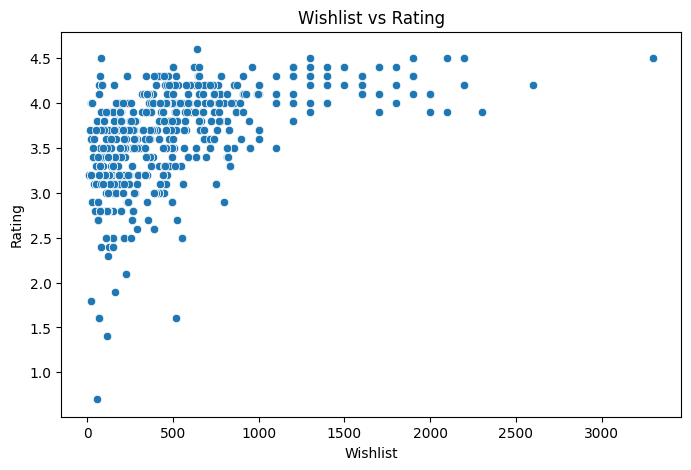

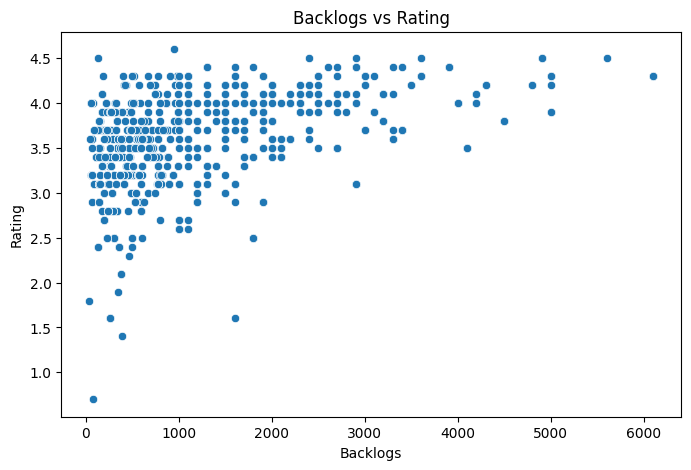

In [138]:
cols = ['Wishlist', 'Backlogs', 'Rating']

for col in cols:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

df_corr = merged_df.dropna(subset=cols)

df_corr[['Wishlist', 'Backlogs', 'Rating']].corr()

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_corr,
    x='Wishlist',
    y='Rating'
)

plt.title('Wishlist vs Rating')
plt.show()


plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_corr,
    x='Backlogs',
    y='Rating'
)

plt.title('Backlogs vs Rating')
plt.show()

### How does user engagement differ across genres?

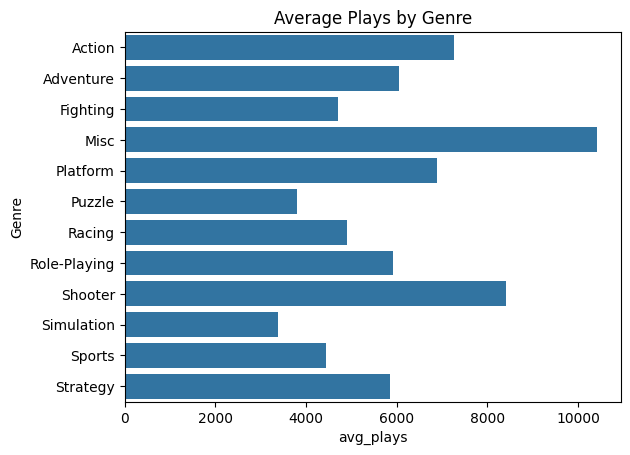

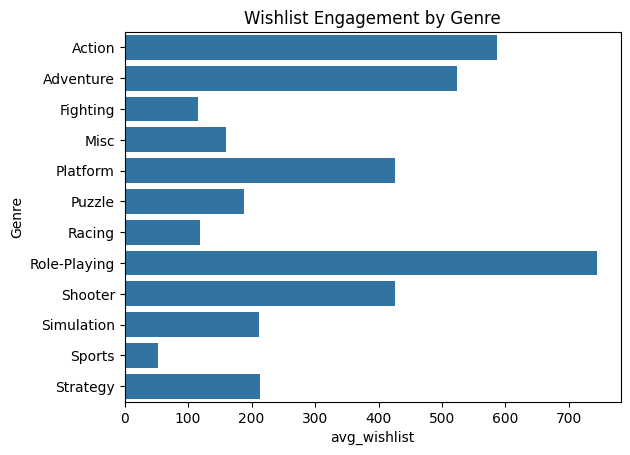

In [141]:
cols = ['Plays', 'Playing', 'Backlogs', 'Wishlist']

for col in cols:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

df_eng = merged_df.dropna(subset=cols)

genre_engagement = df_eng.groupby('Genre').agg(
    avg_plays=('Plays', 'mean'),
    avg_playing=('Playing', 'mean'),
    avg_backlogs=('Backlogs', 'mean'),
    avg_wishlist=('Wishlist', 'mean')
).reset_index()

genre_engagement.sort_values(by='avg_plays', ascending=False)

sns.barplot(
    data=genre_engagement,
    x='avg_plays',
    y='Genre'
)

plt.title('Average Plays by Genre')
plt.show()

sns.barplot(data=genre_engagement, x='avg_wishlist', y='Genre')
plt.title('Wishlist Engagement by Genre')
plt.show()

### What are the top-performing combinations of Genre + Platform?

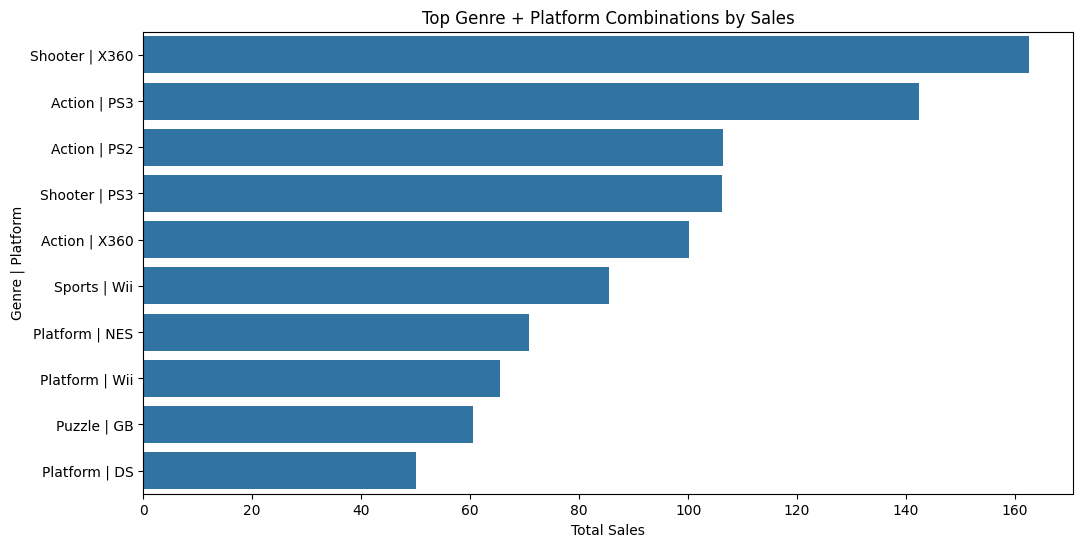

,Genre,Platform,total_sales,avg_sales,game_count
147,Shooter,X360,162.56,4.781176,34
10,Action,PS3,142.43,2.589636,55
9,Action,PS2,106.45,3.130882,34
141,Shooter,PS3,106.19,3.932963,27
18,Action,X360,100.13,2.002600,50
170,Sports,Wii,85.53,21.382500,4
75,Platform,NES,70.79,8.848750,8
85,Platform,Wii,65.47,7.274444,9
93,Puzzle,GB,60.52,30.260000,2
69,Platform,DS,50.14,5.571111,9


In [148]:
merged_df['Global_Sales'] = pd.to_numeric(merged_df['Global_Sales'], errors='coerce')
combo_perf = merged_df.groupby(['Genre', 'Platform']).agg(
    total_sales=('Global_Sales', 'sum'),
    avg_sales=('Global_Sales', 'mean'),
    game_count=('Title', 'count')
).reset_index()

top_combos = combo_perf.sort_values(
    by='total_sales',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_combos,
    x='total_sales',
    y=top_combos['Genre'] + ' | ' + top_combos['Platform']
)

plt.title('Top Genre + Platform Combinations by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Genre | Platform')

plt.show()

top_combos

### What does a regional sales heatmap by genre reveal?

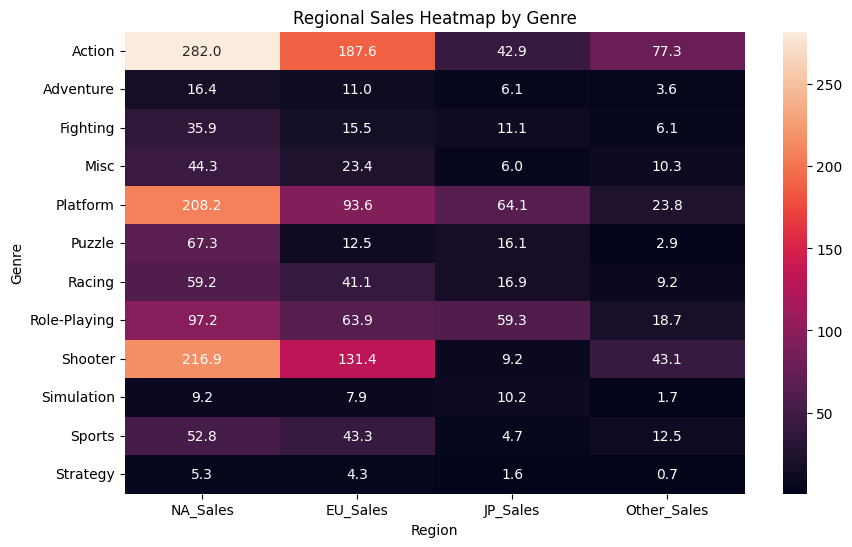

In [149]:
cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

for col in cols:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

genre_region = merged_df.groupby('Genre')[cols].sum()

plt.figure(figsize=(10,6))

sns.heatmap(
    genre_region,
    annot=True,
    fmt='.1f'
)

plt.title('Regional Sales Heatmap by Genre')
plt.xlabel('Region')
plt.ylabel('Genre')

plt.show()